In [1]:
import numpy as np
import paramiko
import pickle

import gzip
import time
from PIL import Image
import cv2

import matplotlib.pyplot as plt

SERVER_HOST = '10.243.85.171'
USERNAME = 'hbalim'
PRIVATE_KEY_PATH = '/Users/hbalim/.ssh/id_ed25519'
REMOTE_UPLOAD_PATH = '/home/hbalim/wdir/FoundationPose/input_data.pkl.gz'
REMOTE_RESPONSE_PATH = '/home/hbalim/wdir/FoundationPose/output_data.pkl.gz'

In [2]:
class SFTPClient:
    def __init__(self, server_host, username, private_key_path, port=22):
        self.transport = paramiko.Transport((server_host, port))

        # Load Ed25519 private key
        private_key = paramiko.Ed25519Key.from_private_key_file(
            private_key_path)

        self.transport.connect(username=username, pkey=private_key)
        self.sftp = paramiko.SFTPClient.from_transport(self.transport)
        print("[Client] Connected to server using Ed25519 key.")

    def send_data(self, data, remote_path):
        serialized = pickle.dumps(data, protocol=pickle.HIGHEST_PROTOCOL)
        with self.sftp.open(remote_path, 'wb') as f:
            f.write(serialized)
        print(f"[Client] Sent data to {remote_path}")

    def receive_response(self, remote_path, poll_interval=2):
        while True:
            try:
                with self.sftp.open(remote_path, 'rb') as f:
                    compressed_data = f.read()
                response = pickle.loads(gzip.decompress(compressed_data))
                print("[Client] Response received.")
                return response
            except IOError:
                print("[Client] Waiting for response...")
                time.sleep(poll_interval)

    def close(self):
        self.sftp.close()
        self.transport.close()
        print("[Client] Connection closed.")


client = SFTPClient(SERVER_HOST, USERNAME, PRIVATE_KEY_PATH)

[Client] Connected to server using Ed25519 key.


In [3]:
# TODO: Should we resize?
client = SFTPClient(SERVER_HOST, USERNAME, PRIVATE_KEY_PATH)
color = cv2.imread('demo_data/found-pose/rgb/0.png')
depth = cv2.imread('demo_data/found-pose/depth/0.png', -1)
data = {'color': color, 'depth': depth, 'first': False}

client.send_data(data, REMOTE_UPLOAD_PATH)
response = client.receive_response(REMOTE_RESPONSE_PATH)
response

[Client] Connected to server using Ed25519 key.
[Client] Sent data to /home/hbalim/wdir/FoundationPose/input_data.pkl.gz
[Client] Waiting for response...
[Client] Waiting for response...
[Client] Waiting for response...


KeyboardInterrupt: 

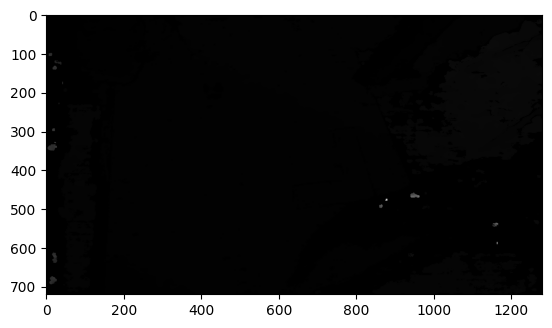

In [2]:
import cv2
import matplotlib.pyplot as plt

color = cv2.imread('images/r.png')
depth = cv2.imread('images/d.png', -1)
data = {'color': color, 'depth': depth, 'first': True}
plt.imshow(color)

In [ ]:
depth.shape

(720, 1280)